In [1]:
import cv2
import numpy as np
import os
import glob
import csv
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


RESIZE_W        = 320        
RESIZE_H        = 240        
FEATURE_SIZE    = 64         
MIN_HAND_AREA   = 500        

# Skin color segmentation
Y_MIN,  Y_MAX  = 0,   255
CR_MIN, CR_MAX = 133, 173
CB_MIN, CB_MAX = 77,  127

# Image filtering
FILTER_KSIZE    = 5          

def stage_resize(img_bgr):
    return cv2.resize(img_bgr, (RESIZE_W, RESIZE_H),
                      interpolation=cv2.INTER_NEAREST)


def stage_skin_segmentation(img_bgr):
    ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)

    lower = np.array([Y_MIN,  CR_MIN, CB_MIN], dtype=np.uint8)
    upper = np.array([Y_MAX,  CR_MAX, CB_MAX], dtype=np.uint8)

    skin_mask = cv2.inRange(ycrcb, lower, upper)
    return skin_mask  


def stage_image_filtering(skin_mask):
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    filtered = cv2.morphologyEx(
        skin_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    return filtered


def stage_crop_and_resize(filtered_mask):
    
    contours, _ = cv2.findContours(filtered_mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return cv2.resize(filtered_mask,
                          (FEATURE_SIZE, FEATURE_SIZE),
                          interpolation=cv2.INTER_NEAREST)

    largest = max(contours, key=cv2.contourArea)
    if cv2.contourArea(largest) < MIN_HAND_AREA:
        return cv2.resize(filtered_mask,
                          (FEATURE_SIZE, FEATURE_SIZE),
                          interpolation=cv2.INTER_NEAREST)

    x, y, w, h = cv2.boundingRect(largest)

    side = max(w, h)
    cx   = x + w // 2
    cy   = y + h // 2
    x0   = max(0, cx - side // 2)
    y0   = max(0, cy - side // 2)
    x1   = min(filtered_mask.shape[1], x0 + side)
    y1   = min(filtered_mask.shape[0], y0 + side)

    crop = filtered_mask[y0:y1, x0:x1]
    return cv2.resize(crop, (FEATURE_SIZE, FEATURE_SIZE),
                      interpolation=cv2.INTER_NEAREST)


def stage_feature_extraction(binary_64):
    
    H, W  = binary_64.shape        # 64, 64
    bw    = (binary_64 > 0).astype(np.uint32)

    half_h      = H // 2           # 32
    half_w      = W // 2           # 32
    centre_size = H // 4           # 16

    def safe_norm(val, max_val):
        if max_val == 0:
            return 0
        return min(255, int(val * 255 // max_val))

    f0_raw = int(bw.sum())

    col_idx = np.arange(W, dtype=np.uint32)
    row_idx = np.arange(H, dtype=np.uint32)
    f1_raw  = int((bw * col_idx[np.newaxis, :]).sum())
    f2_raw  = int((bw * row_idx[:, np.newaxis]).sum())

    f3_raw = int(bw[:half_h, :].sum())
    f4_raw = int(bw[half_h:, :].sum())
    f5_raw = int(bw[:, :half_w].sum())
    f6_raw = int(bw[:, half_w:].sum())

    r0     = (H - centre_size) // 2
    c0     = (W - centre_size) // 2
    f7_raw = int(bw[r0:r0+centre_size, c0:c0+centre_size].sum())

    f0 = safe_norm(f0_raw, H * W)
    f1 = safe_norm(f1_raw, max(1, f0_raw) * (W - 1))
    f2 = safe_norm(f2_raw, max(1, f0_raw) * (H - 1))
    f3 = safe_norm(f3_raw, half_h * W)
    f4 = safe_norm(f4_raw, half_h * W)
    f5 = safe_norm(f5_raw, H * half_w)
    f6 = safe_norm(f6_raw, H * half_w)
    f7 = safe_norm(f7_raw, centre_size * centre_size)

    grid_features = []

    grid_size = 4
    cell_h = H // grid_size
    cell_w = W // grid_size

    for row in range(grid_size):

        for col in range(grid_size):

            y1 = row * cell_h
            y2 = (row + 1) * cell_h if row < grid_size - 1 else H

            x1 = col * cell_w
            x2 = (col + 1) * cell_w if col < grid_size - 1 else W

            region = bw[y1:y2, x1:x2]

            count = int(region.sum())

            region_norm = safe_norm(
                count,
                region.shape[0] * region.shape[1]
            )

            grid_features.append(region_norm)

    return np.array(
        [f0, f1, f2, f3, f4, f5, f6, f7] + grid_features,
        dtype=np.uint8
    )


def preprocess_and_extract(img_bgr, debug=False):
    
    stages = {}

    s1 = stage_resize(img_bgr)                 ; stages['1_resize_320x240']    = s1
    s2 = stage_skin_segmentation(s1)           ; stages['3_skin_mask']         = s2
    s3 = stage_image_filtering(s2)             ; stages['4_filtered_mask']     = s3
    s4 = stage_crop_and_resize(s3)             ; stages['5_crop_64x64']        = s4
    features = stage_feature_extraction(s4)

    if debug:
        return features, stages
    return features
    

    
def build_dataset(dataset_root, output_csv="features.csv"):
    
    classes     = ['a', 'i', 'o', 'u',
           '3', '4', '5', '8', '9',
           'c', 'l', 'v', 'x', 'y']   
    extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp')

    rows = []
    for label in classes:
        folder = os.path.join(dataset_root, label)
        if not os.path.isdir(folder):
            print(f"  [WARN] folder not found: {folder}")
            continue

        images = []
        for ext in extensions:
            images.extend(glob.glob(os.path.join(folder, ext)))

        print(f"  Processing {label}: {len(images)} images")
        for img_path in images:
            img = cv2.imread(img_path)
            if img is None:
                continue
            feats = preprocess_and_extract(img)
            rows.append([label] + feats.tolist())

    with open(output_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(
    ['label', 'f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7'] +
    [f'r{i}' for i in range(16)]
)
        writer.writerows(rows)

    print(f"\n  Saved {len(rows)} samples -> {output_csv}")
    return rows


def train_decision_tree(csv_path="features.csv", max_depth=5):
   
    from sklearn.tree import DecisionTreeClassifier, export_text
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import classification_report
    import pandas as pd

    df = pd.read_csv(csv_path)
    feature_cols = ['f0','f1','f2','f3','f4','f5','f6','f7'] + [f'r{i}' for i in range(16)]

    X = df[feature_cols].values
    y  = df['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    clf = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    clf.fit(X_train, y_train)

    print("=" * 60)
    print(f"Test Accuracy: {clf.score(X_test, y_test)*100:.1f}%")
    print("=" * 60)
    print(classification_report(y_test, clf.predict(X_test)))
        

    y_pred = clf.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:\n")
    print(cm)

    plt.figure(figsize=(10,8))

    plt.imshow(cm, cmap='Blues')

    plt.title("Confusion Matrix")

    plt.colorbar()

    classes = clf.classes_

    plt.xticks(range(len(classes)), classes)
    plt.yticks(range(len(classes)), classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, cm[i, j],
                     ha='center',
                     va='center',
                     color='black')

    plt.show()
    print("\n-- Decision Tree (copy thresholds into VHDL) --")
    feature_names = ['f0','f1','f2','f3','f4','f5','f6','f7'] + [f'r{i}' for i in range(16)]

    print(export_text(clf, feature_names=feature_names))
    return clf

  Processing a: 70 images
  Processing i: 70 images
  Processing o: 70 images
  Processing u: 70 images
  Processing 3: 70 images
  Processing 4: 70 images
  Processing 5: 70 images
  Processing 8: 70 images
  Processing 9: 70 images
  Processing c: 70 images
  Processing l: 70 images
  Processing v: 70 images
  Processing x: 70 images
  Processing y: 70 images

  Saved 980 samples -> features.csv
Test Accuracy: 92.3%
              precision    recall  f1-score   support

           3       0.93      0.93      0.93        14
           4       0.92      0.79      0.85        14
           5       0.93      1.00      0.97        14
           8       0.76      0.93      0.84        14
           9       0.93      0.93      0.93        14
           a       1.00      0.93      0.96        14
           c       1.00      1.00      1.00        14
           i       1.00      0.79      0.88        14
           l       1.00      1.00      1.00        14
           o       0.93      1.00    

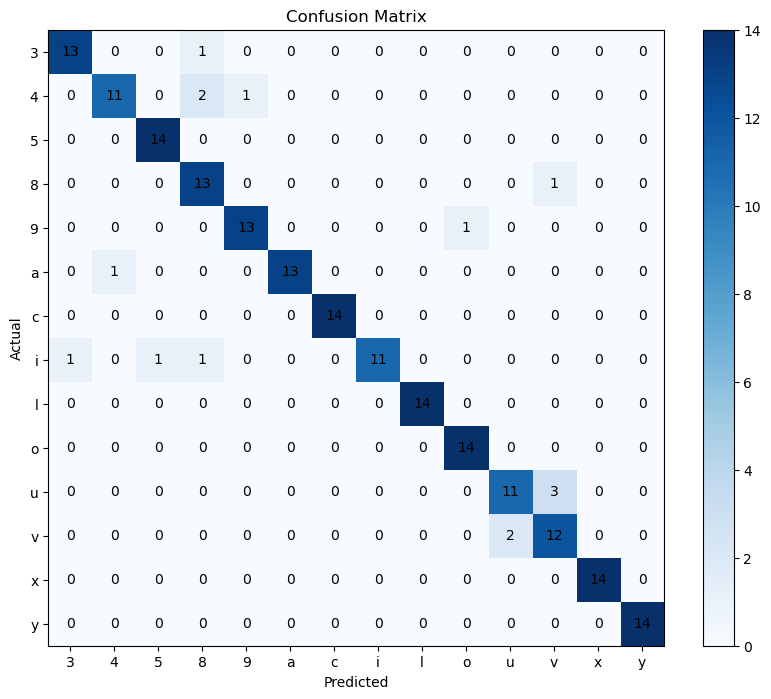


-- Decision Tree (copy thresholds into VHDL) --
|--- r4 <= 24.50
|   |--- r2 <= 121.50
|   |   |--- r9 <= 206.50
|   |   |   |--- f4 <= 105.00
|   |   |   |   |--- r0 <= 5.00
|   |   |   |   |   |--- class: v
|   |   |   |   |--- r0 >  5.00
|   |   |   |   |   |--- class: 9
|   |   |   |--- f4 >  105.00
|   |   |   |   |--- f4 <= 118.00
|   |   |   |   |   |--- class: u
|   |   |   |   |--- f4 >  118.00
|   |   |   |   |   |--- class: v
|   |   |--- r9 >  206.50
|   |   |   |--- r7 <= 39.00
|   |   |   |   |--- r2 <= 63.00
|   |   |   |   |   |--- r3 <= 16.50
|   |   |   |   |   |   |--- f7 <= 235.50
|   |   |   |   |   |   |   |--- class: v
|   |   |   |   |   |   |--- f7 >  235.50
|   |   |   |   |   |   |   |--- class: u
|   |   |   |   |   |--- r3 >  16.50
|   |   |   |   |   |   |--- class: v
|   |   |   |   |--- r2 >  63.00
|   |   |   |   |   |--- class: v
|   |   |   |--- r7 >  39.00
|   |   |   |   |--- f6 <= 79.50
|   |   |   |   |   |--- class: l
|   |   |   |   |--- f6 >  

In [3]:
dataset_root = r"C:\Users\user\Downloads\Dataset"
output_csv = "features.csv"

build_dataset(dataset_root, output_csv)

clf = train_decision_tree("features.csv", max_depth=10)
